# BrushCue Example: CRT Monitor Filter

<a href="https://colab.research.google.com/github/ditotechnologies/brushcue/blob/main/examples/crt_monitor_filter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

You can use this tool online at https://www.brushcue.com/tools/crt-monitor-filter

In [ ]:
!pip install brushcue

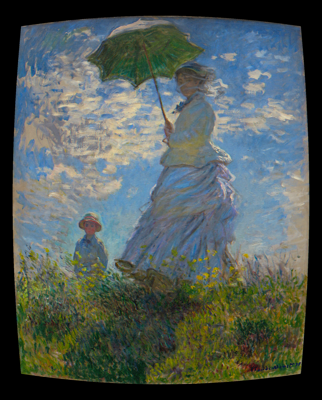

In [1]:
import brushcue
from PIL import Image
import io

input_image_1 = brushcue.composition_monet_women_with_parasol() # insert your own image here
glow_layer_transform_2 = brushcue.transform2_identity()
crt_shader_body_3 = brushcue.string_constant("let dims_u = textureDimensions(input_texture, 0);\nlet dims = vec2<f32>(dims_u);\nlet uv = (vec2<f32>(position) + vec2<f32>(0.5, 0.5)) / dims;\nlet centered = uv * 2.0 - vec2<f32>(1.0, 1.0);\nlet r2 = dot(centered, centered);\nlet warped = centered * (1.0 + curvature * r2);\nlet crt_uv = warped * 0.5 + vec2<f32>(0.5, 0.5);\nif (crt_uv.x < 0.0 || crt_uv.x > 1.0 || crt_uv.y < 0.0 || crt_uv.y > 1.0) {\n    return vec4<f32>(0.0, 0.0, 0.0, input.a);\n}\nlet px = max(rgb_separation, 0.0) / max(dims.x, 1.0);\nlet red = sample(input_texture, crt_uv + vec2<f32>(px, 0.0)).r;\nlet green = sample(input_texture, crt_uv).g;\nlet blue = sample(input_texture, crt_uv - vec2<f32>(px, 0.0)).b;\nvar color = vec3<f32>(red, green, blue);\nlet scan = 1.0 - clamp(scanline_intensity, 0.0, 1.0) * (0.5 + 0.5 * sin(crt_uv.y * scanline_count * 6.2831853));\nlet triad = 0.94 + 0.06 * sin(crt_uv.x * dims.x * 2.0943951);\nlet grain_seed = dot(position, vec2<u32>(1973u, 9277u));\nlet grain = fract(sin(f32(grain_seed) * 0.0001) * 43758.5453);\ncolor = color * scan * triad + (grain - 0.5) * noise_amount;\nreturn vec4<f32>(clamp(color, vec3<f32>(0.0), vec3<f32>(1.0)), input.a);")
crt_shader_helpers_4 = brushcue.string_constant(" ")
color_profile_srgb_5 = brushcue.color_profile_s_r_g_b()
color_profile_srgb_6 = brushcue.color_profile_s_r_g_b()
bool_constant_7 = brushcue.bool_constant(True)
crt_contrast_8 = brushcue.composition_contrast_adjustment(input_image_1, 1.2)
string_constant_9 = brushcue.string_constant("scanline_count")
noise_amount_key_10 = brushcue.string_constant("noise_amount")
curvature_key_11 = brushcue.string_constant("curvature")
rgb_separation_key_12 = brushcue.string_constant("rgb_separation")
crt_shader_settings_13 = brushcue.dictionary_create()
scanline_intensity_key_14 = brushcue.string_constant("scanline_intensity")
crt_saturation_15 = brushcue.composition_saturation_adjust(crt_contrast_8, 1.25)
add_scanline_intensity_16 = brushcue.float_add_to_dictionary(crt_shader_settings_13, scanline_intensity_key_14, 0.32)
add_chromatic_separation_17 = brushcue.float_add_to_dictionary(add_scanline_intensity_16, rgb_separation_key_12, 2.0)
add_screen_curvature_18 = brushcue.float_add_to_dictionary(add_chromatic_separation_17, curvature_key_11, 0.1)
add_noise_amount_19 = brushcue.float_add_to_dictionary(add_screen_curvature_18, noise_amount_key_10, 0.035)
add_scanline_count_20 = brushcue.float_add_to_dictionary(add_noise_amount_19, string_constant_9, 360.0)
crt_screen_shader_21 = brushcue.composition_custom_transformer_shader(crt_saturation_15, crt_shader_body_3, crt_shader_helpers_4, color_profile_srgb_5, color_profile_srgb_6, add_scanline_count_20, bool_constant_7)
crt_vignette_22 = brushcue.composition_vignette(crt_screen_shader_21, 0.62, 0.25, 0.45)
crt_glow_blur_23 = brushcue.composition_gaussian_blur(crt_vignette_22, 3.0)
crt_glow_strength_24 = brushcue.composition_brightness_adjust(crt_glow_blur_23, 0.18)
crt_glow_add_25 = brushcue.composition_blend_add(crt_glow_strength_24, crt_vignette_22, glow_layer_transform_2)

ctx = brushcue.Context()
result = crt_glow_add_25.execute(ctx)
composition = result.as_composition()
data_bytes = composition.to_image_bytes(ctx)
img = Image.open(io.BytesIO(data_bytes))
img.thumbnail((400, 400)) # remove this line for full resolution
img
